<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/8_Regresion_No_Lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [143]:
#Cargamos librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.special as special
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import r2_score

# Leer CSV

In [144]:
#Cargar archivo csv desde seaborn
mallorca= pd.read_csv("Mallorca.csv")
mallorca.head(5)

,id,scrape_id,last_scraped,source,name,host_id,host_name,host_since,host_location,host_response_time,...,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count
0,69998.0,20241214212418,2024-12-15,city scrape,COZY HIDEAWAY LOFT... MI AMOR...,353156,Lor,2011-01-19,"Palma, Spain",within an hour,...,2024-10-26,4.95,4.92,4.93,4.95,4.97,4.89,4.81,t,2
1,106833.0,20241214212418,2024-12-15,city scrape,Villa with a big pool in Mallorca,551974,Xisco,2011-05-02,"Palma de Mallorca, Spain",NaN,...,2024-09-11,4.89,4.81,4.81,4.89,4.92,4.52,4.63,f,1
2,159218.0,20241214212418,2024-12-15,city scrape,Farmhouse in Nature -ET-3025,763897,Gabriel,2011-06-30,"Inca, Spain",within an hour,...,2024-10-27,4.92,4.88,4.93,4.96,4.95,4.82,4.75,f,1
3,164185.0,20241214212418,2024-12-15,city scrape,Corazón de Palma-Habitación con baño privado.,788123,Maria,2011-07-07,"Costa d'en Blanes, Spain",within an hour,...,2024-10-26,4.75,4.72,4.64,4.93,4.90,4.93,4.68,f,1
4,166820.0,20241214212418,2024-12-15,city scrape,Guest House with Great sea views - Principal Room,794829,Toni,2011-07-08,"Balearic Islands, Spain",within an hour,...,2024-10-08,4.67,4.75,4.35,4.87,4.91,4.94,4.60,t,4


# Eliminar Outliers

In [145]:
cuantitativas=mallorca.select_dtypes(include=["float64","int64","float","int"])
cualitativas=mallorca.select_dtypes(include=["object","datetime","category"])
y=cuantitativas

percentile25=y.quantile(0.25)
percentile75=y.quantile(0.75)
iqr= percentile75-percentile25

Limite_Superior_iqr= percentile75+1.5*iqr
Limite_Inferior_iqr= percentile25-1.5*iqr
iqr=cuantitativas[(y<=Limite_Superior_iqr)&y>=(Limite_Inferior_iqr)]
iqr2=iqr.fillna(round(iqr.mean(),1))
rango_intercuartilico=pd.concat([cualitativas,iqr2],axis=1)
rango_intercuartilico

,last_scraped,source,name,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_location.1,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count
0,2024-12-15,city scrape,COZY HIDEAWAY LOFT... MI AMOR...,Lor,2011-01-19,"Palma, Spain",within an hour,100%,91%,t,...,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
1,2024-12-15,city scrape,Villa with a big pool in Mallorca,Xisco,2011-05-02,"Palma de Mallorca, Spain",NaN,NaN,88%,f,...,8,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2024-12-15,city scrape,Farmhouse in Nature -ET-3025,Gabriel,2011-06-30,"Inca, Spain",within an hour,100%,100%,t,...,31,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,2024-12-15,city scrape,Corazón de Palma-Habitación con baño privado.,Maria,2011-07-07,"Costa d'en Blanes, Spain",within an hour,100%,99%,NaN,...,12,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,2024-12-15,city scrape,Guest House with Great sea views - Principal Room,Toni,2011-07-08,"Balearic Islands, Spain",within an hour,100%,100%,f,...,33,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16862,2024-12-15,city scrape,Very Cosy and very central,Martina,2024-07-09,"Palma, Spain",within an hour,100%,100%,f,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
16863,2024-12-15,city scrape,Habitación 5,Holidu,2024-07-02,"Palma, Spain",within an hour,100%,99%,f,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83
16864,2024-12-15,city scrape,Habitación 4,Holidu,2024-07-02,"Palma, Spain",within an hour,100%,99%,f,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83
16865,2024-12-15,city scrape,Habitación 3,Holidu,2024-07-02,"Palma, Spain",within an hour,100%,99%,f,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83


# Limpieza de Nulos

In [146]:
mallorca_cuanti=mallorca.select_dtypes(include=["float64","int64","float","int"])
mallorca_cuali=mallorca.select_dtypes(include=["object","datetime","category"])

cuantias_mean=mallorca_cuanti.fillna(round(mallorca_cuanti.mean(),1))
cualis_bfill=mallorca_cuali.fillna(method="bfill")
cualis_ffill=mallorca_cuali.fillna(method="ffill")

mallorca_casi_sin_nulos = pd.concat([cuantias_mean,cualis_ffill],axis=1)
mallorca = mallorca_casi_sin_nulos.drop(columns=['neighbourhood_group_cleansed'])
mallorca

/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_20401/2187155546.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cualis_bfill=mallorca_cuali.fillna(method="bfill")
/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_20401/2187155546.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cualis_ffill=mallorca_cuali.fillna(method="ffill")


,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,neighbourhood,neighbourhood_cleansed,property_type,room_type,price,has_availability,calendar_last_scraped,first_review,last_review,instant_bookable
0,6.999800e+04,20241214212418,353156,2,5,39.569870,2.654640,2,1.0,1.0,...,"Palma de Mallorca, Balearic Islands, Spain",Palma de Mallorca,Entire loft,NaN,$76.00,t,2024-12-15,2012-01-24,2024-10-26,t
1,1.068330e+05,20241214212418,551974,1,1,39.614580,3.301000,4,1.0,2.0,...,"Palma de Mallorca, Balearic Islands, Spain",Sant Llorenç des Cardassar,Entire villa,Entire home/apt,$200.00,t,2024-12-15,2012-06-05,2024-09-11,f
2,1.592180e+05,20241214212418,763897,1,1,39.738390,2.897450,3,1.0,1.0,...,"Selva, Balearic Islands, Spain",Selva,Entire cottage,Entire home/apt,$90.00,t,2024-12-15,2011-09-15,2024-10-27,f
3,1.641850e+05,20241214212418,788123,2,3,39.572710,2.644480,2,1.0,1.0,...,"Palma de Mallorca, Balearic Islands, Spain",Palma de Mallorca,Private room in guest suite,Private room,$50.00,t,2024-12-15,2011-08-16,2024-10-26,f
4,1.668200e+05,20241214212418,794829,4,5,39.678940,2.500520,2,1.0,1.0,...,"Palma de Mallorca, Balearic Islands, Spain",Banyalbufar,Private room in home,Private room,$70.00,t,2024-12-15,2011-08-08,2024-10-08,t
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16862,1.308224e+18,20241214212418,588497055,1,1,39.573649,2.648082,1,0.5,1.0,...,"Palma, Illes Balears, Spain",Palma de Mallorca,Private room in condo,Private room,$49.00,t,2024-12-15,2024-12-06,2024-12-06,f
16863,1.308462e+18,20241214212418,587006009,1002,1152,39.607365,2.556080,2,1.0,1.0,...,"Palma, Illes Balears, Spain",Puigpunyent,Private room in villa,Private room,$142.00,t,2024-12-15,2024-12-06,2024-12-06,t
16864,1.308462e+18,20241214212418,587006009,1002,1152,39.607365,2.556080,2,1.0,1.0,...,"Palma, Illes Balears, Spain",Puigpunyent,Private room in villa,Private room,$142.00,t,2024-12-15,2024-12-06,2024-12-06,t
16865,1.308462e+18,20241214212418,587006009,1002,1152,39.607365,2.556080,2,1.0,1.0,...,"Palma, Illes Balears, Spain",Puigpunyent,Private room in villa,Private room,$142.00,t,2024-12-15,2024-12-06,2024-12-06,t


# Preparación de Variables

In [147]:
#Convertimos las variables str en numéricas
mallorca['host_response_rate'] = mallorca['host_response_rate'].str.replace('%','').astype(float)
mallorca['host_acceptance_rate'] = mallorca['host_acceptance_rate'].str.replace('%','').astype(float)
mallorca['price'] = mallorca['price'].str.replace('[$,]', '', regex=True).astype(float)

In [148]:
#Juntamos todas las variables objetivo en una sola
#("reviews_per_month" no forma parte de mi CSV)
variables = ['host_response_rate','host_acceptance_rate','host_total_listings_count','accommodates','price']
variables_objetivo = mallorca[variables]
variables_objetivo

,host_response_rate,host_acceptance_rate,host_total_listings_count,accommodates,price
0,100.0,91.0,5,2,76.0
1,100.0,88.0,1,4,200.0
2,100.0,100.0,1,3,90.0
3,100.0,99.0,3,2,50.0
4,100.0,100.0,5,2,70.0
...,...,...,...,...,...
16862,100.0,100.0,1,1,49.0
16863,100.0,99.0,1152,2,142.0
16864,100.0,99.0,1152,2,142.0
16865,100.0,99.0,1152,2,142.0


# Función 1

In [149]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

# Función 2

In [150]:
def  func2 (x, a, b, c):
     return a*x + b*x + c*x

# host_response_rate

In [151]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= mallorca[['review_scores_rating']]
Var_Dep= mallorca[['host_response_rate']]
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

Función 1

In [152]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, mallorca['review_scores_rating'], mallorca['host_response_rate'])

In [153]:
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([6.30857702e-02, 7.32624454e-01, 9.03455928e+01])

In [154]:
# Predicciones
y_pred1 = func1(x, *parametros1)

In [155]:
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1

,review_scores_rating
0,95.517843
1,95.436640
2,95.477185
3,95.248932
4,95.142780
...,...
16862,95.182492
16863,95.182492
16864,95.182492
16865,95.182492


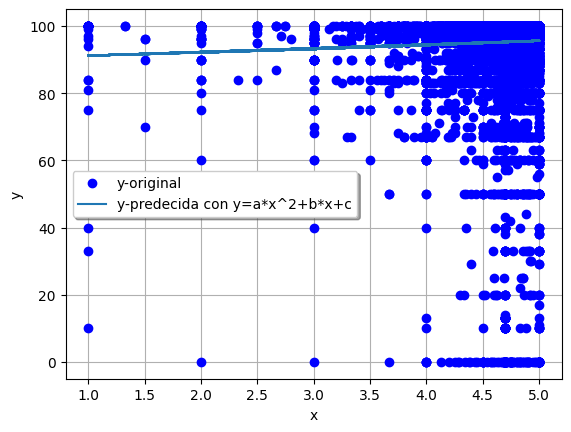

In [156]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con y=a*x^2+b*x+c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [157]:
#Calculamos el coeficiente de determinación del modelo
CDHRR1 = r2_score(y, y_pred1) 
CDHRR1 

0.0010768365255642287

In [158]:
#Calculamos el coeficiente de correlación del modelo
CCHRR1 = np.sqrt(CDHRR1)
CCHRR1

0.03281518742235413

Función 2

In [159]:
parametros2, covs= curve_fit(func2, mallorca['review_scores_rating'], mallorca['host_response_rate'])
print("Parámetros:", parametros2)

y_pred2 = func1(x, *parametros2)
print("Predicciones:", y_pred2)

Parámetros: [  77.48375541   77.48375756 -134.79303474]
Predicciones:        review_scores_rating
0               2147.297282
1               2096.901847
2               2122.029829
3               1981.482045
4               1916.891586
...                     ...
16862           1940.996783
16863           1940.996783
16864           1940.996783
16865           1940.996783
16866           1940.996783

[16867 rows x 1 columns]


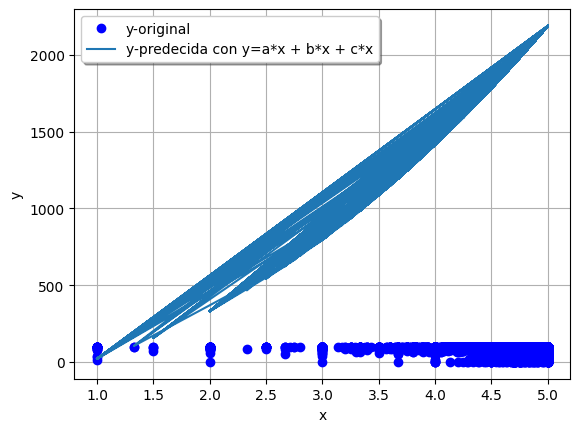

In [160]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred2, label="y-predecida con y=a*x + b*x + c*x")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [161]:
CDHRR2 = r2_score(y, y_pred2) 
print("Coeficiiente de determinación:",CDHRR2)
CCHRR2 = np.sqrt(CDHRR2)
print("Coeficiiente de correlación:",CCHRR2)

Coeficiiente de determinación: -17655.138029103888
Coeficiiente de correlación: nan


/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_20401/194194766.py:3: RuntimeWarning: invalid value encountered in sqrt
  CCHRR2 = np.sqrt(CDHRR2)


# host_acceptance_rate

In [162]:
Vars_Indep= mallorca[['review_scores_rating']]
Var_Dep= mallorca[['host_acceptance_rate']]
x= Vars_Indep
y= Var_Dep

Función 1

In [163]:
parametros1, covs= curve_fit(func1, mallorca['review_scores_rating'], mallorca['host_acceptance_rate'])
print("Parámetros:", parametros1)

y_pred1 = func1(x, *parametros1)
print("Predicciones:", y_pred1)

Parámetros: [-0.92579156  5.34590874 86.5371226 ]
Predicciones:        review_scores_rating
0                 90.315163
1                 90.540996
2                 90.428913
3                 91.042017
4                 91.312021
...                     ...
16862             91.212158
16863             91.212158
16864             91.212158
16865             91.212158
16866             91.212158

[16867 rows x 1 columns]


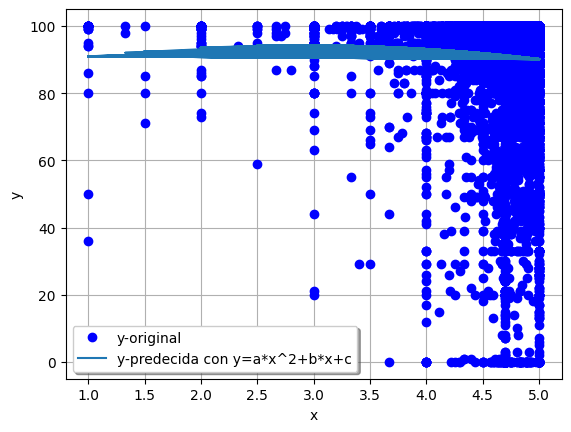

In [164]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con y=a*x^2+b*x+c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [165]:
CDHAR1 = r2_score(y, y_pred1) 
print("Coeficiiente de determinación:",CDHAR1)
CCHAR1 = np.sqrt(CDHAR1)
print("Coeficiiente de correlación:",CCHAR1)

Coeficiiente de determinación: 0.0020279199967084827
Coeficiiente de correlación: 0.04503243272030152


Función 2

In [166]:
parametros2, covs= curve_fit(func2, mallorca['review_scores_rating'], mallorca['host_acceptance_rate'])
print("Parámetros:", parametros2)

y_pred2 = func1(x, *parametros2)
print("Predicciones:", y_pred2)

Parámetros: [  77.1420429    77.14202134 -134.99030973]
Predicciones:        review_scores_rating
0               2137.035602
1               2086.862419
2               2111.879583
3               1971.951635
4               1907.646029
...                     ...
16862           1931.644918
16863           1931.644918
16864           1931.644918
16865           1931.644918
16866           1931.644918

[16867 rows x 1 columns]


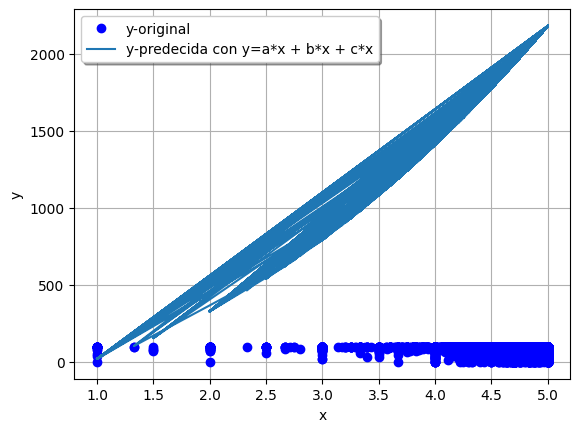

In [167]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred2, label="y-predecida con y=a*x + b*x + c*x")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [168]:
CDHAR2 = r2_score(y, y_pred2) 
print("Coeficiiente de determinación:",CDHAR2)
CCHAR2 = np.sqrt(CDHAR2)
print("Coeficiiente de correlación:",CCHAR2)

Coeficiiente de determinación: -9364.032313093303
Coeficiiente de correlación: nan


/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_20401/4143894140.py:3: RuntimeWarning: invalid value encountered in sqrt
  CCHAR2 = np.sqrt(CDHAR2)


# host_total_listings_count

In [169]:
Vars_Indep= mallorca[['review_scores_rating']]
Var_Dep= mallorca[['host_total_listings_count']]
x= Vars_Indep
y= Var_Dep

Función 1

In [170]:
parametros1, covs= curve_fit(func1, mallorca['review_scores_rating'], mallorca['host_total_listings_count'])
print("Parámetros:", parametros1)

y_pred1 = func1(x, *parametros1)
print("Predicciones:", y_pred1)

Parámetros: [-96.42811316 511.09522099  83.30628023]
Predicciones:        review_scores_rating
0                250.497781
1                276.763226
2                263.717289
3                335.349277
4                367.129885
...                     ...
16862            355.356799
16863            355.356799
16864            355.356799
16865            355.356799
16866            355.356799

[16867 rows x 1 columns]


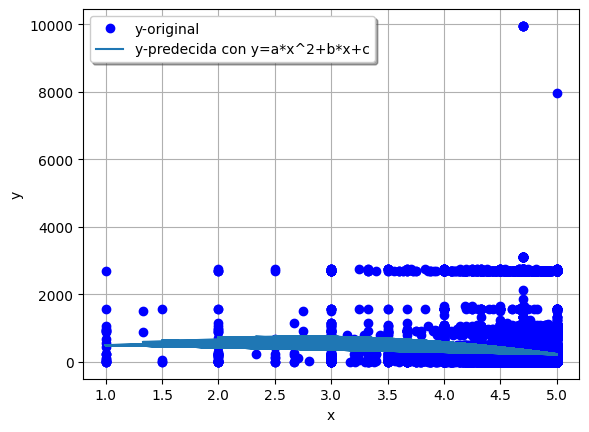

In [171]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con y=a*x^2+b*x+c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [172]:
CDHTLC1 = r2_score(y, y_pred1) 
print("Coeficiiente de determinación:",CDHTLC1)
CCHTLC1 = np.sqrt(CDHTLC1)
print("Coeficiiente de correlación:",CCHTLC1)

Coeficiiente de determinación: 0.023238202866454727
Coeficiiente de correlación: 0.15244081758654643


Función 2

In [173]:
parametros2, covs= curve_fit(func2, mallorca['review_scores_rating'], mallorca['host_total_listings_count'])
print("Parámetros:", parametros2)

y_pred2 = func1(x, *parametros2)
print("Predicciones:", y_pred2)

Parámetros: [  94.61095479   94.61095479 -117.52249876]
Predicciones:        review_scores_rating
0               2669.006647
1               2607.471682
2               2638.154015
3               2466.539204
4               2387.671512
...                     ...
16862           2417.104980
16863           2417.104980
16864           2417.104980
16865           2417.104980
16866           2417.104980

[16867 rows x 1 columns]


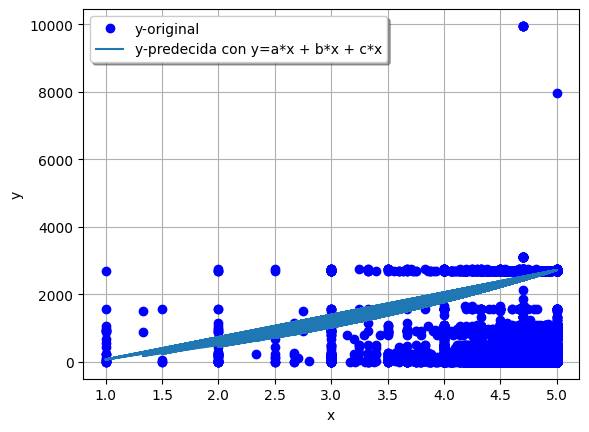

In [174]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred2, label="y-predecida con y=a*x + b*x + c*x")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [175]:
CDHTLC2 = r2_score(y, y_pred2) 
print("Coeficiiente de determinación:",CDHTLC2)
CCHTLC2 = np.sqrt(CDHTLC2)
print("Coeficiiente de correlación:",CCHTLC2)

Coeficiiente de determinación: -9.368194563171109
Coeficiiente de correlación: nan


/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_20401/1025224444.py:3: RuntimeWarning: invalid value encountered in sqrt
  CCHTLC2 = np.sqrt(CDHTLC2)


# accommodates

In [176]:
Vars_Indep= mallorca[['review_scores_rating']]
Var_Dep= mallorca[['accommodates']]
x= Vars_Indep
y= Var_Dep

Función 1

In [177]:
parametros1, covs= curve_fit(func1, mallorca['review_scores_rating'], mallorca['accommodates'])
print("Parámetros:", parametros1)

y_pred1 = func1(x, *parametros1)
print("Predicciones:", y_pred1)

Parámetros: [ 0.08201867 -0.5504546   6.44772246]
Predicciones:        review_scores_rating
0                  5.732635
1                  5.717238
2                  5.724863
3                  5.683609
4                  5.665836
...                     ...
16862              5.672378
16863              5.672378
16864              5.672378
16865              5.672378
16866              5.672378

[16867 rows x 1 columns]


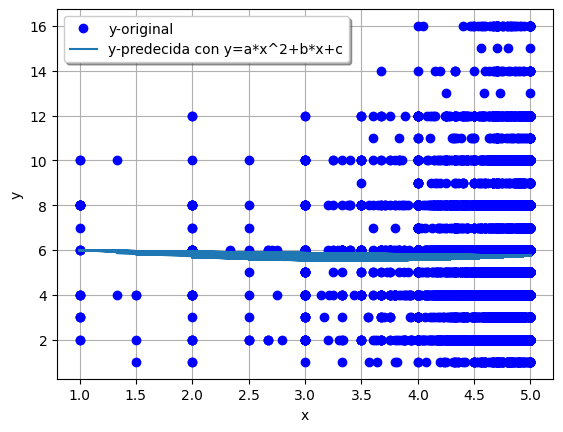

In [178]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con y=a*x^2+b*x+c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [179]:
CDA1 = r2_score(y, y_pred1) 
print("Coeficiiente de determinación:",CDA1)
CCA1 = np.sqrt(CDA1)
print("Coeficiiente de correlación:",CCA1)

Coeficiiente de determinación: 0.00040132248111557356
Coeficiiente de correlación: 0.020033034745529036


Función 2

In [180]:
parametros2, covs= curve_fit(func2, mallorca['review_scores_rating'], mallorca['accommodates'])
print("Parámetros:", parametros2)

y_pred2 = func1(x, *parametros2)
print("Predicciones:", y_pred2)

Parámetros: [-53.45156189 -74.12262115 128.77865139]
Predicciones:        review_scores_rating
0              -1547.825219
1              -1511.820059
2              -1529.774532
3              -1429.304664
4              -1383.093758
...                     ...
16862          -1400.342670
16863          -1400.342670
16864          -1400.342670
16865          -1400.342670
16866          -1400.342670

[16867 rows x 1 columns]


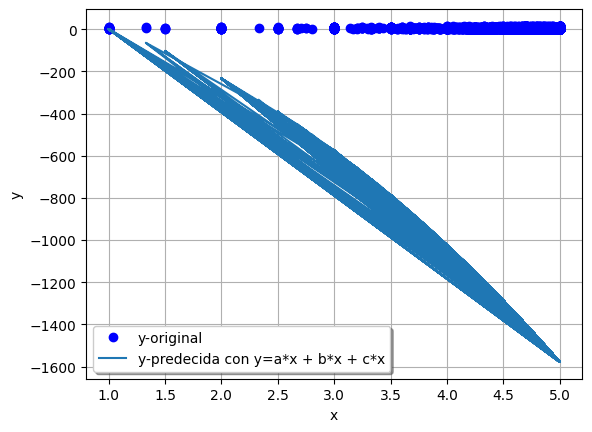

In [181]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred2, label="y-predecida con y=a*x + b*x + c*x")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [182]:
CDA2 = r2_score(y, y_pred2) 
print("Coeficiiente de determinación:",CDA2)
CCA2 = np.sqrt(CDA2)
print("Coeficiiente de correlación:",CCA2)

Coeficiiente de determinación: -277185.26822514704
Coeficiiente de correlación: nan


/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_20401/892828771.py:3: RuntimeWarning: invalid value encountered in sqrt
  CCA2 = np.sqrt(CDA2)


# price

In [183]:
Vars_Indep= mallorca[['review_scores_rating']]
Var_Dep= mallorca[['price']]
x= Vars_Indep
y= Var_Dep

Función 1

In [184]:
parametros1, covs= curve_fit(func1, mallorca['review_scores_rating'], mallorca['price'])
print("Parámetros:", parametros1)

y_pred1 = func1(x, *parametros1)
print("Predicciones:", y_pred1)

Parámetros: [  11.67250174 -163.64558807  925.06682405]
Predicciones:        review_scores_rating
0                401.026637
1                403.953927
2                402.479777
3                411.111101
4                415.406351
...                     ...
16862            413.778124
16863            413.778124
16864            413.778124
16865            413.778124
16866            413.778124

[16867 rows x 1 columns]


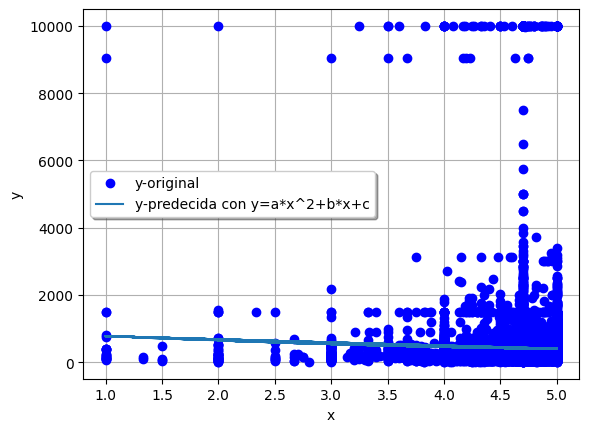

In [185]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con y=a*x^2+b*x+c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [186]:
CDP1 = r2_score(y, y_pred1) 
print("Coeficiiente de determinación:",CDP1)
CCP1 = np.sqrt(CDP1)
print("Coeficiiente de correlación:",CCP1)

Coeficiiente de determinación: 0.0005494816044213646
Coeficiiente de correlación: 0.02344102396273176


Función 2

In [187]:
parametros2, covs= curve_fit(func2, mallorca['review_scores_rating'], mallorca['price'])
print("Parámetros:", parametros2)

y_pred2 = func1(x, *parametros2)
print("Predicciones:", y_pred2)

Parámetros: [-41.48166878 -41.4818978  170.65025114]
Predicciones:        review_scores_rating
0              -1051.089732
1              -1024.110041
2              -1037.562553
3               -962.318915
4               -927.739778
...                     ...
16862           -940.644732
16863           -940.644732
16864           -940.644732
16865           -940.644732
16866           -940.644732

[16867 rows x 1 columns]


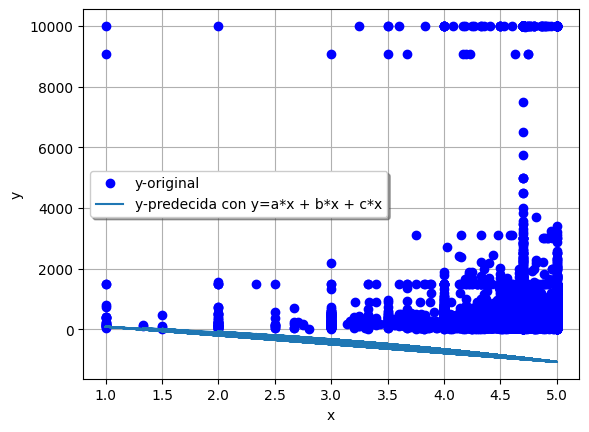

In [188]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred2, label="y-predecida con y=a*x + b*x + c*x")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [189]:
CDP2 = r2_score(y, y_pred2) 
print("Coeficiiente de determinación:",CDP2)
CCP2 = np.sqrt(CDP2)
print("Coeficiiente de correlación:",CCP2)

Coeficiiente de determinación: -1.3930259011976696
Coeficiiente de correlación: nan


/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_20401/104366933.py:3: RuntimeWarning: invalid value encountered in sqrt
  CCP2 = np.sqrt(CDP2)


# Tablas de Coeficientes

In [190]:
Modelo_1 = {
    "Variable": ["host_response_rate","host_acceptance_rate","host_total_listings_count","accommodates","price"],
    "C. Determinación": [CDHRR1,CDHAR1,CDHTLC1,CDA1,CDP1],
    "C. Correlación": [CCHRR1,CCHAR1,CCHTLC1,CCA1,CCP1]
}

df_1 = pd.DataFrame(Modelo_1)
print(df_1)

                    Variable  C. Determinación  C. Correlación
0         host_response_rate          0.001077        0.032815
1       host_acceptance_rate          0.002028        0.045032
2  host_total_listings_count          0.023238        0.152441
3               accommodates          0.000401        0.020033
4                      price          0.000549        0.023441


In [191]:
Modelo_2 = {
    "Variable": ["host_response_rate","host_acceptance_rate","host_total_listings_count","accommodates","price"],
    "C. Determinación": [CDHRR2,CDHAR2,CDHTLC2,CDA2,CDP2],
    "C. Correlación": [CCHRR2,CCHAR2,CCHTLC2,CCA2,CCP2]
}

df_2 = pd.DataFrame(Modelo_2)
print(df_2)

                    Variable  C. Determinación  C. Correlación
0         host_response_rate     -17655.138029             NaN
1       host_acceptance_rate      -9364.032313             NaN
2  host_total_listings_count         -9.368195             NaN
3               accommodates    -277185.268225             NaN
4                      price         -1.393026             NaN
